# 稳态热模型，采取拟合参数的方法

## import需要的库

In [299]:
import os,gzip,pickle
from keys import DataDir,Cols
import numpy as np
import pandas as pd
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
from torch.utils.data import random_split

# 设置字体
matplotlib.rcParams['font.family'] = 'Microsoft YaHei, Times New Roman'
# 全局设置字号
plt.rcParams.update({
    'font.size': 20,  # 基础字号
    'axes.titlesize': 20,  # 标题字号
    'axes.labelsize': 20,  # 坐标轴标签字号
    'xtick.labelsize': 20,  # x轴刻度标签字号
    'ytick.labelsize': 20,  # y轴刻度标签字号
    'legend.fontsize': 18  # 图例字号
})
# 解决负号显示问题
matplotlib.rcParams['axes.unicode_minus'] = False

## 读取数据

In [246]:
with gzip.open(
    r'D:\Devs\Single_Stack_MLJ\data\processed\Test data Hyzenis\2025.04.08-8.30-2025.04.11-17.30-10s-1# gzip',
    'rb'
) as f:
    df_Hyzenis = pickle.load(f)

In [247]:
df_date_Hyzenis = df_Hyzenis.query(
    f"'2025-04-08 00:00:00'<{Cols.date_time}<'2025-04-11 16:00:00'"
)

df_temp_Hyzenis = df_date_Hyzenis

### 滤波

In [248]:
from scipy.ndimage.filters import gaussian_filter1d

# 设置高斯滤波的标准差
sigma = 1.0

# 进行高斯滤波
df_temp_Hyzenis[Cols.temp_out] = gaussian_filter1d(df_temp_Hyzenis[Cols.temp_out], sigma)

C:\Users\Orz\AppData\Local\Temp\ipykernel_2180\2617071021.py:1: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d
C:\Users\Orz\AppData\Local\Temp\ipykernel_2180\2617071021.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp_Hyzenis[Cols.temp_out] = gaussian_filter1d(df_temp_Hyzenis[Cols.temp_out], sigma)


### 计算生成温度变化值

In [249]:
df_temp_Hyzenis[Cols.delta_temp_out] = df_temp_Hyzenis[Cols.temp_out].shift(-1) - df_temp_Hyzenis[Cols.temp_out]
# 删除最后一行
df_temp_Hyzenis = df_temp_Hyzenis.drop(df_temp_Hyzenis.index[-1])

C:\Users\Orz\AppData\Local\Temp\ipykernel_2180\744405329.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp_Hyzenis[Cols.delta_temp_out] = df_temp_Hyzenis[Cols.temp_out].shift(-1) - df_temp_Hyzenis[Cols.temp_out]


### 绘图观察

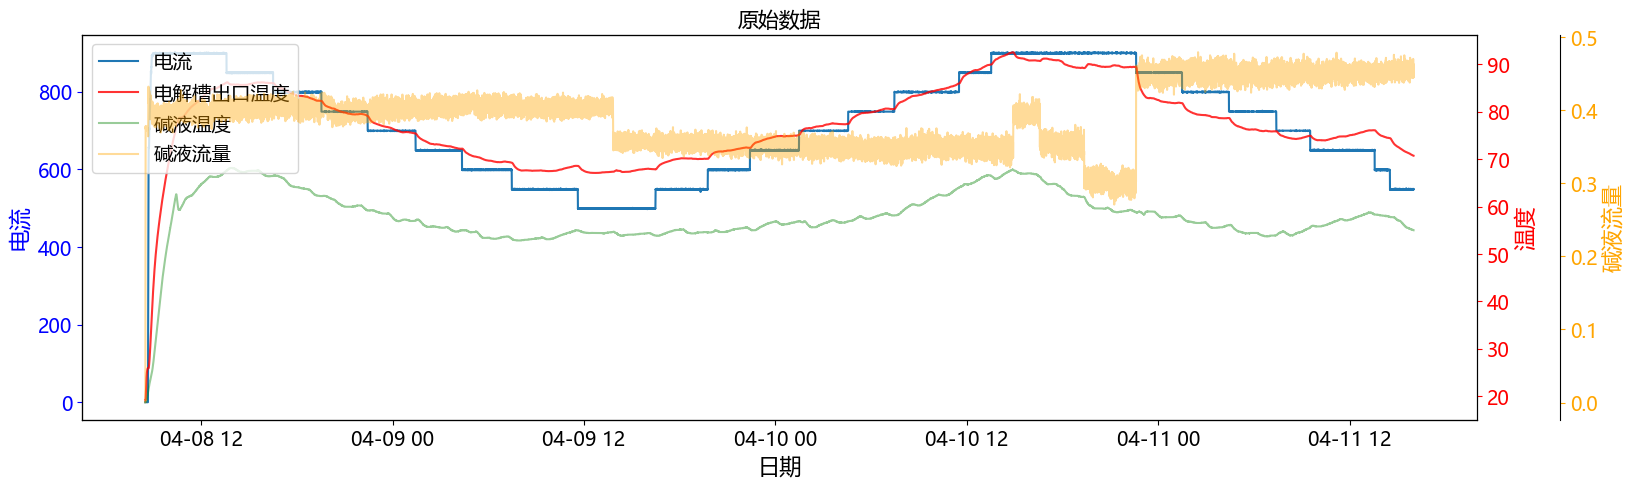

In [250]:
# 创建图表和子图
fig, ax1 = plt.subplots(figsize=(18, 5))
plt.title('原始数据', fontsize = 15)

# 绘制第一个因变量的曲线
ax1.plot(df_temp_Hyzenis[Cols.date_time],df_temp_Hyzenis[Cols.current], label = '电流')
ax1.set_xlabel('日期')
ax1.set_ylabel('电流', color='b')
ax1.tick_params('y', colors='b')

# 创建第二个y轴
ax2 = ax1.twinx()

# 绘制第二个因变量的曲线
ax2.plot(df_temp_Hyzenis[Cols.date_time],df_temp_Hyzenis[Cols.temp_out], alpha=0.8, c = 'r', label = '电解槽出口温度')
ax2.plot(df_temp_Hyzenis[Cols.date_time],df_temp_Hyzenis[Cols.lye_temp], c = 'green', alpha = 0.4, label = '碱液温度')
ax2.set_ylabel('温度', color='r')
ax2.tick_params('y', colors='r')

# 创建第三个y轴
ax3 = ax1.twinx()

# 绘制第三个因变量的曲线
ax3.plot(df_temp_Hyzenis[Cols.date_time],df_temp_Hyzenis[Cols.lye_flow], c = 'orange', alpha = 0.4, label = '碱液流量')
ax3.set_ylabel('碱液流量', color='orange')
ax3.spines['right'].set_position(('outward', 60))
ax3.tick_params('y', colors='orange')

# 添加图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax2.legend(lines + lines2 + lines3, labels + labels2 + labels3, loc='upper left')

# 显示图表
plt.show()

In [286]:
df_choose_Hyzenis = df_temp_Hyzenis.copy()

In [288]:
# 计算前后 100 个点（窗口大小为 201）的极差
window_size = 200
df_choose_Hyzenis['temp_diff'] = df_choose_Hyzenis[Cols.temp_out].rolling(window=window_size, center=True, min_periods=1).apply(lambda x: x.max() - x.min())

# 筛选出温度变化值小于 0.3% 的行
# df_choose_Hyzenis = df_choose_Hyzenis[df_choose_Hyzenis['temp_diff'] < 0.5]
df_choose_Hyzenis = df_choose_Hyzenis[df_choose_Hyzenis[Cols.delta_temp_out] < 0.1]

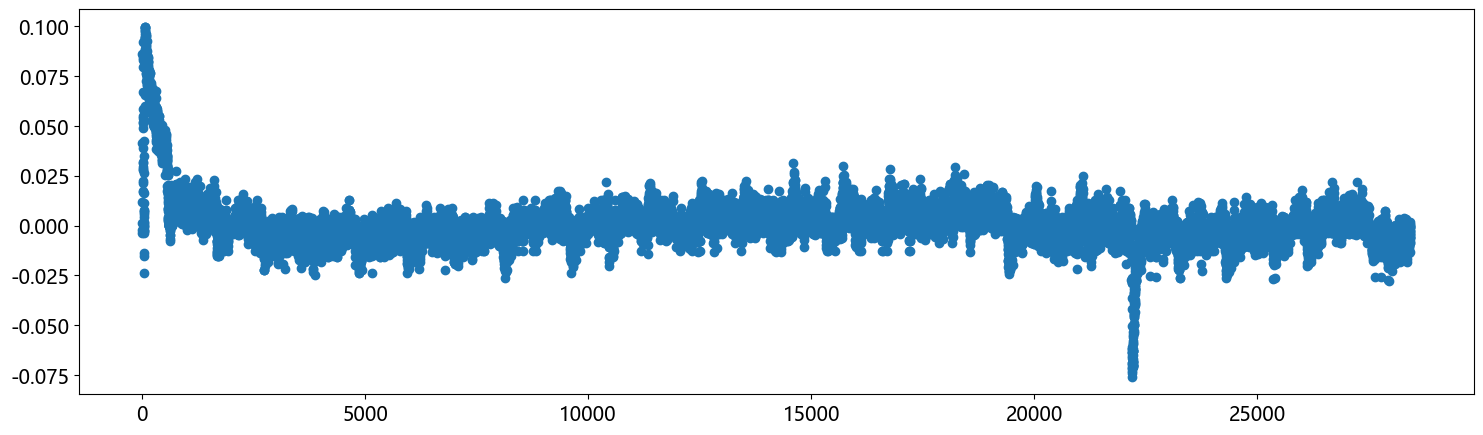

In [289]:
plt.figure(figsize=(18,5))
# plt.scatter(range(len(df_choose_Hyzenis)),df_choose_Hyzenis[Cols.temp_out])
plt.scatter(range(len(df_choose_Hyzenis[Cols.delta_temp_out])),df_choose_Hyzenis[Cols.delta_temp_out])

## 定义拟合函数

In [13]:
# 定义拟合函数
def deltaT_cal_fit(Statistics, tg1, Surface_heat_transfer_coefficient, Heat_capacity_lye, tc1, tc2, Heat_capacity_stack, Num_cells = 31, Sample_time = 10):
    """稳态热模型函数

    Args:
        Statistics (Dataframe): 实验数据
        Surface_heat_transfer_coefficient (float): 电解槽对空气散热的表面传热系数 W/℃
        Heat_capacity_lye (float): 碱液比热容
        c1 (float): (float): 碱液带入热量修正系数
        c2 (float): (float): 碱液带出热量修正系数
        Heat_capacity_stack (float): 电解槽比热容
        Num_cells (int, optional): 小室数. Defaults to 31.
        sample_time (int, optional): 采样时间间隔. Defaults to 10.

    Returns:
        float: 温度变化率
    """
    cell_voltage = Statistics[0]
    current = Statistics[1]
    temp_out = Statistics[2]
    temp_environment = Statistics[3]
    lye_flow = Statistics[4]
    lye_temp = Statistics[5]

    Tref = 25  # 参考点温度: K
    z = 2  # 单位摩尔反应转移的电子数: mol

    Delta_H0_H2O = -2.86E5  # 参考点状态下的焓变(单位：J / mol)
    Delta_H0_H2 = 0  # 参考点状态下的焓变(单位：J / mol)
    Delta_H0_O2 = 0  # 参考点状态下的焓变(单位：J / mol)

    Cp0_H2O = 75  # 参考点状态下的水热容(单位：J / (K * mol))
    Cp0_H2 = 29  # 参考点状态下的氢气热容(单位：J / (K * mol))
    Cp0_O2 = 29  # 参考点状态下的氧气热容(单位：J / (K * mol))

    Delta_H_H2 = Cp0_H2 * (temp_out - Tref) + Delta_H0_H2
    Delta_H_O2 = Cp0_O2 * (temp_out - Tref) + Delta_H0_O2
    Delta_H_H2O = Cp0_H2O * (temp_out - Tref) + Delta_H0_H2O
    Delta_H = Delta_H_H2 + 0.5 * Delta_H_O2 - Delta_H_H2O

    Vtn_cell = Delta_H / (z * 96485)

    lye_flow = lye_flow * 1.328 * 1E6 / 3600 # m3/h → g/s

    # Heat_capacity_stack = Heat_capacity_stack * 1E7
    # Rt_stack = Rt_stack * 1E-2
    # Heat_capacity_lye = Heat_capacity_lye

    Qdot_gen = Num_cells * (cell_voltage - Vtn_cell) * current * tg1 # 单位 W

    Qdot_loss = (temp_out - temp_environment) * Surface_heat_transfer_coefficient # 单位 W

    Qdot_lye_in = Heat_capacity_lye * lye_flow * lye_temp * tc1 # 单位 W

    Qdot_lye_out = Heat_capacity_lye * lye_flow * temp_out * tc2 # 单位 W

    Qdot_cool = Qdot_lye_out - Qdot_lye_in # 单位 W

    delta_Temp_H = (Qdot_gen - Qdot_loss - Qdot_cool) / Heat_capacity_stack # 单位 ℃/s
    
    delta_Temp_H_sample = delta_Temp_H * Sample_time

    return delta_Temp_H_sample

## 提取自变量与因变量

In [14]:
# 检查是否有 GPU 可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cuda


In [290]:
feature_cols = [Cols.cell_voltage, Cols.current, Cols.temp_out, Cols.temp_environment, Cols.lye_flow, Cols.lye_temp]
statistics = df_choose_Hyzenis[feature_cols]

delta_temp_out_obs = df_choose_Hyzenis[Cols.delta_temp_out]

statistics_torch = torch.tensor(statistics.values.T, dtype=torch.float32)
delta_temp_out_obs_torch = torch.tensor(delta_temp_out_obs.values, dtype=torch.float32)

statistics_torch = statistics_torch.to(device)
delta_temp_out_obs_torch = delta_temp_out_obs_torch.to(device)

In [291]:
# 计算训练集和测试集的大小
total_size = statistics_torch.shape[1]
train_size = int(0.8 * total_size)
test_size = total_size - train_size

# 随机划分数据
train_indices, test_indices = random_split(range(total_size), [train_size, test_size])

# 根据划分的索引获取训练集和测试集
statistics_torch_train = statistics_torch[:, train_indices.indices]
delta_temp_out_obs_torch_train = delta_temp_out_obs_torch[train_indices.indices]

statistics_torch_test = statistics_torch[:, test_indices.indices]
delta_temp_out_obs_torch_test = delta_temp_out_obs_torch[test_indices.indices]

print(f"训练集大小: {statistics_torch_train.shape[1]}")
print(f"测试集大小: {statistics_torch_test.shape[1]}")

训练集大小: 22750
测试集大小: 5688


## 拟合经验参数

In [17]:
# # 随机赋值初始化
# params1 = {name: abs(torch.randn(1)) * 1E7 for name in [
#     'Heat_capacity_stack'
# ]}
# params2 = {name: abs(torch.randn(1)) * 1E3 for name in [
#     'Surface_heat_transfer_coefficient'
# ]}
# params3 = {name: abs(torch.randn(1)) * 1E1 for name in [
#     'Heat_capacity_lye'
# ]}
# params4 = {name: abs(torch.randn(1)) for name in [
#     'g1', 'c1', 'c2'
# ]}

# 给定值初始化
params1 = {name: torch.tensor(2.2E6, dtype=torch.float32) for name in [
    'Heat_capacity_stack'
]}
params2 = {name: torch.tensor(50, dtype=torch.float32) for name in [
    'Surface_heat_transfer_coefficient'
]}
params3 = {name: torch.tensor(3.3, dtype=torch.float32) for name in [
    'Heat_capacity_lye'
]}
params4 = {name: torch.tensor(0.9, dtype=torch.float32) for name in [
    'tg1', 'tc1', 'tc2'
]}

params = {**params1, **params2, **params3, **params4}

for param in params.values():
    param.requires_grad = True

params = {k: torch.nn.Parameter(v.to(device)) for k, v in params.items()}

### 梯度下降方法拟合

In [202]:
# 定义损失函数
class CustomMSELoss(torch.nn.Module):
    def __init__(self):
        super(CustomMSELoss, self).__init__()
        self.mse_loss = torch.nn.MSELoss()

    def forward(self, input, target):
        return self.mse_loss(input, target) * 1e6

# 使用自定义损失函数
criterion = CustomMSELoss()

# 分四类设置学习率
lr1 = 1e4
lr2 = 1e1
lr3 = 1e-2
lr4 = 1e-3

# 设置训练边界
tolerance = 1e-6

# 分离参数，按照不同学习率分类
params1_list = [params['Heat_capacity_stack']]
params2_list = [params['Surface_heat_transfer_coefficient']]
params3_list = [params['Heat_capacity_lye']]
params4_list = [params['tg1'], params['tc1'], params['tc2']]

# 使用单个优化器管理多参数组
optimizer = torch.optim.AdamW([
    {'params': params1_list, 'lr': lr1},
    {'params': params2_list, 'lr': lr2},
    {'params': params3_list, 'lr': lr3},
    {'params': params4_list, 'lr': lr4}
], weight_decay=1e-4)

# 早停策略参数
patience = 1000
best_test_loss = float('inf')
counter = 0

# 训练循环
num_epochs = 100000

for epoch in range(num_epochs):
    # 训练步骤
    optimizer.zero_grad()
    
    # 训练数据前向传播
    delta_temp_out_pred_train = deltaT_cal_fit(statistics_torch_train, **params)
    train_loss = criterion(delta_temp_out_pred_train, delta_temp_out_obs_torch_train)
    
    # 反向传播与优化
    train_loss.backward()
    optimizer.step()
    
    # 验证步骤
    with torch.no_grad():
        cell_voltage_pred_test = deltaT_cal_fit(statistics_torch_test, **params)
        test_loss = criterion(cell_voltage_pred_test, delta_temp_out_obs_torch_test)
    
    # 每50个epoch打印信息
    if epoch % 50 == 0:
        print(f'Epoch {epoch}, Train Loss: {train_loss.item():.4e}, test Loss: {test_loss.item():.4e}')
    
    # 早停策略
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}, best test loss: {best_test_loss:.4e}")
            break
    
    # 收敛条件检查
    if train_loss.item() < tolerance:
        print(f"训练损失达到收敛条件 (<{tolerance})")
        break

# 最终结果输出
print("训练完成，最终验证损失：", best_test_loss.item())


Epoch 0, Train Loss: 8.9750e+07, test Loss: 6.1890e+05
Epoch 50, Train Loss: 7.4525e+06, test Loss: 7.0175e+06
Epoch 100, Train Loss: 6.1935e+06, test Loss: 5.8514e+06
Epoch 150, Train Loss: 5.4571e+06, test Loss: 5.1657e+06
Epoch 200, Train Loss: 4.9354e+06, test Loss: 4.6793e+06
Epoch 250, Train Loss: 4.5246e+06, test Loss: 4.2948e+06
Epoch 300, Train Loss: 4.1804e+06, test Loss: 3.9711e+06
Epoch 350, Train Loss: 3.8808e+06, test Loss: 3.6881e+06
Epoch 400, Train Loss: 3.6131e+06, test Loss: 3.4347e+06
Epoch 450, Train Loss: 3.3698e+06, test Loss: 3.2040e+06
Epoch 500, Train Loss: 3.1458e+06, test Loss: 2.9913e+06
Epoch 550, Train Loss: 2.9374e+06, test Loss: 2.7933e+06
Epoch 600, Train Loss: 2.7420e+06, test Loss: 2.6076e+06
Epoch 650, Train Loss: 2.5576e+06, test Loss: 2.4324e+06
Epoch 700, Train Loss: 2.3829e+06, test Loss: 2.2662e+06
Epoch 750, Train Loss: 2.2165e+06, test Loss: 2.1080e+06
Epoch 800, Train Loss: 2.0576e+06, test Loss: 1.9569e+06
Epoch 850, Train Loss: 1.9054e+06,

In [203]:
print(params)

{'Heat_capacity_stack': Parameter containing:
tensor(1917.0863, requires_grad=True), 'Surface_heat_transfer_coefficient': Parameter containing:
tensor(27.2913, requires_grad=True), 'Heat_capacity_lye': Parameter containing:
tensor(1.0119, requires_grad=True), 'tg1': Parameter containing:
tensor(0.4571, requires_grad=True), 'tc1': Parameter containing:
tensor(0.9695, requires_grad=True), 'tc2': Parameter containing:
tensor(0.9399, requires_grad=True)}


In [ ]:
torch.save(params, r'D:\Devs\Simulation-Platform\src\Model\Static_Model\Static_Thermal_params.pth')

## 检查拟合效果

### 预测结果

In [310]:
params['Heat_capacity_lye'] = torch.nn.Parameter(torch.tensor(3.2, dtype=torch.float32))
params['Heat_capacity_stack'] = torch.nn.Parameter(torch.tensor(10E5, dtype=torch.float32))
params['Surface_heat_transfer_coefficient'] = torch.nn.Parameter(torch.tensor(30.5, dtype=torch.float32))
params['tg1'] = torch.nn.Parameter(torch.tensor(1, dtype=torch.float32))
params['tc1'] = torch.nn.Parameter(torch.tensor(1.01, dtype=torch.float32))
params['tc2'] = torch.nn.Parameter(torch.tensor(0.95, dtype=torch.float32))

delta_temp_out_pred_train = deltaT_cal_fit(statistics_torch_train, **params)
train_loss = criterion(delta_temp_out_pred_train, delta_temp_out_obs_torch_train)
delta_temp_out_pred_test = deltaT_cal_fit(statistics_torch_test, **params)
test_loss = criterion(delta_temp_out_pred_test, delta_temp_out_obs_torch_test)
print(train_loss, test_loss)

tensor(74.7682, device='cuda:0', grad_fn=<MulBackward0>) tensor(78.2387, device='cuda:0', grad_fn=<MulBackward0>)


Text(0, 0.5, '温度')

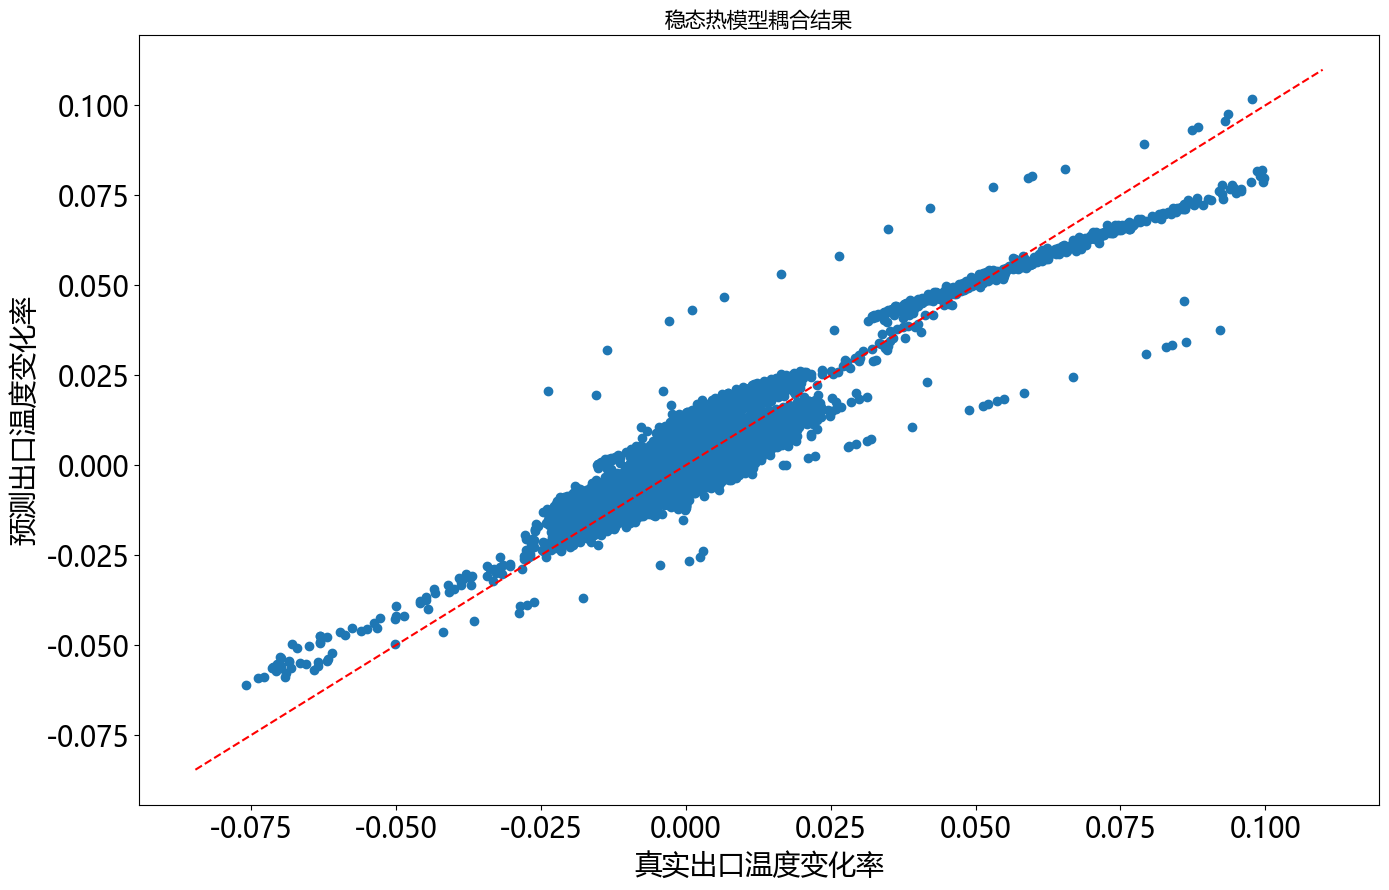

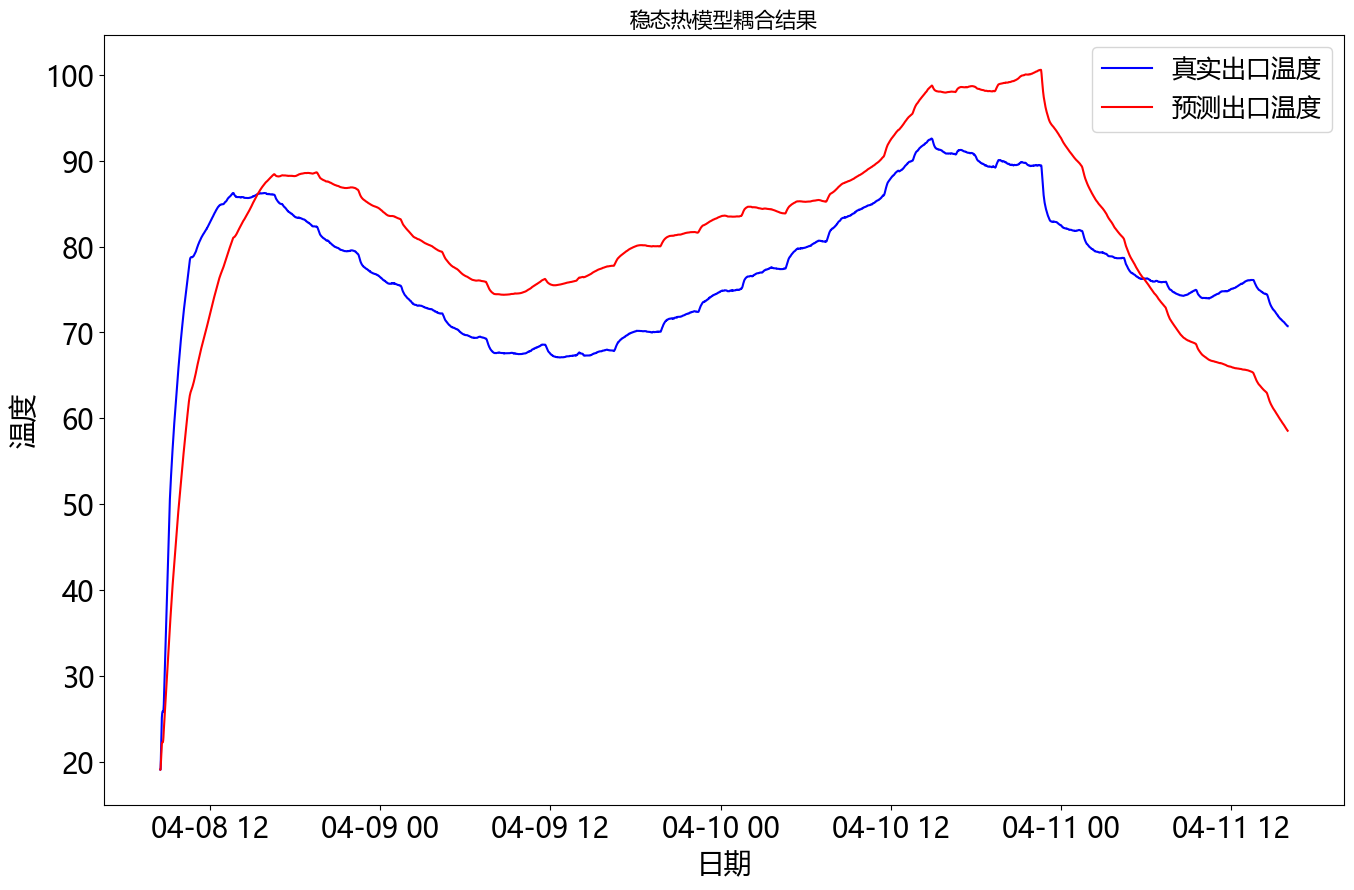

In [300]:
statistics_simulation = df_choose_Hyzenis[feature_cols]
statistics_simulation_torch = torch.tensor(statistics_simulation.values.T, dtype=torch.float32).to(device)

delta_temp_out_pred = deltaT_cal_fit(Statistics=statistics_simulation_torch,
                                    **params)

delta_temp_out_pred = delta_temp_out_pred.cpu().detach().numpy()

delta_temp_out_pred_process = (delta_temp_out_pred + df_choose_Hyzenis[Cols.delta_temp_out]) / 2

initial_temperature = df_choose_Hyzenis[Cols.temp_out].iloc[0]
pre_temp_out = initial_temperature + delta_temp_out_pred.cumsum()

pre_temp_out_process = (pre_temp_out + df_choose_Hyzenis[Cols.temp_out]) / 2

plt.figure(figsize = (16, 10))
plt.scatter(df_choose_Hyzenis[Cols.delta_temp_out], delta_temp_out_pred_process)
# plt.scatter(df_choose_Hyzenis[Cols.delta_temp_out], delta_temp_out_pred)

# 获取当前的 Axes 对象
ax = plt.gca()
# 获取坐标轴的范围
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
# 确定对角线的端点
diag_min = min(x_min, y_min)
diag_max = max(x_max, y_max)
# 绘制对角线
plt.plot([diag_min, diag_max], [diag_min, diag_max], color='red', linestyle='--')
plt.title('稳态热模型耦合结果', fontsize = 15)
plt.xlabel('真实出口温度变化率')
plt.ylabel('预测出口温度变化率')

plt.figure(figsize = (16, 10))
plt.plot(df_choose_Hyzenis[Cols.date_time],df_choose_Hyzenis[Cols.temp_out], c = 'b', label = '真实出口温度')
plt.plot(df_choose_Hyzenis[Cols.date_time],pre_temp_out_process, c = 'r', label = '预测出口温度')
# plt.plot(df_choose_Hyzenis[Cols.date_time],pre_temp_out, c = 'r', label = '预测出口温度')
plt.legend()
plt.title('稳态热模型耦合结果', fontsize = 15)
plt.xlabel('日期')
plt.ylabel('温度')

In [315]:
from sklearn.metrics import r2_score

r2 = r2_score(df_choose_Hyzenis[Cols.delta_temp_out], delta_temp_out_pred_process)
print(r2)

0.822274195751266


In [294]:
from scipy.stats import gaussian_kde

# 计算核密度估计
x = df_choose_Hyzenis[Cols.delta_temp_out]
y = delta_temp_out_pred_process
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# 按密度排序以确保高密度点显示在上方
idx = z.argsort()
x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

Text(0.09, -0.075, 'R$^2$=0.922\nMSE=7.477E-5')

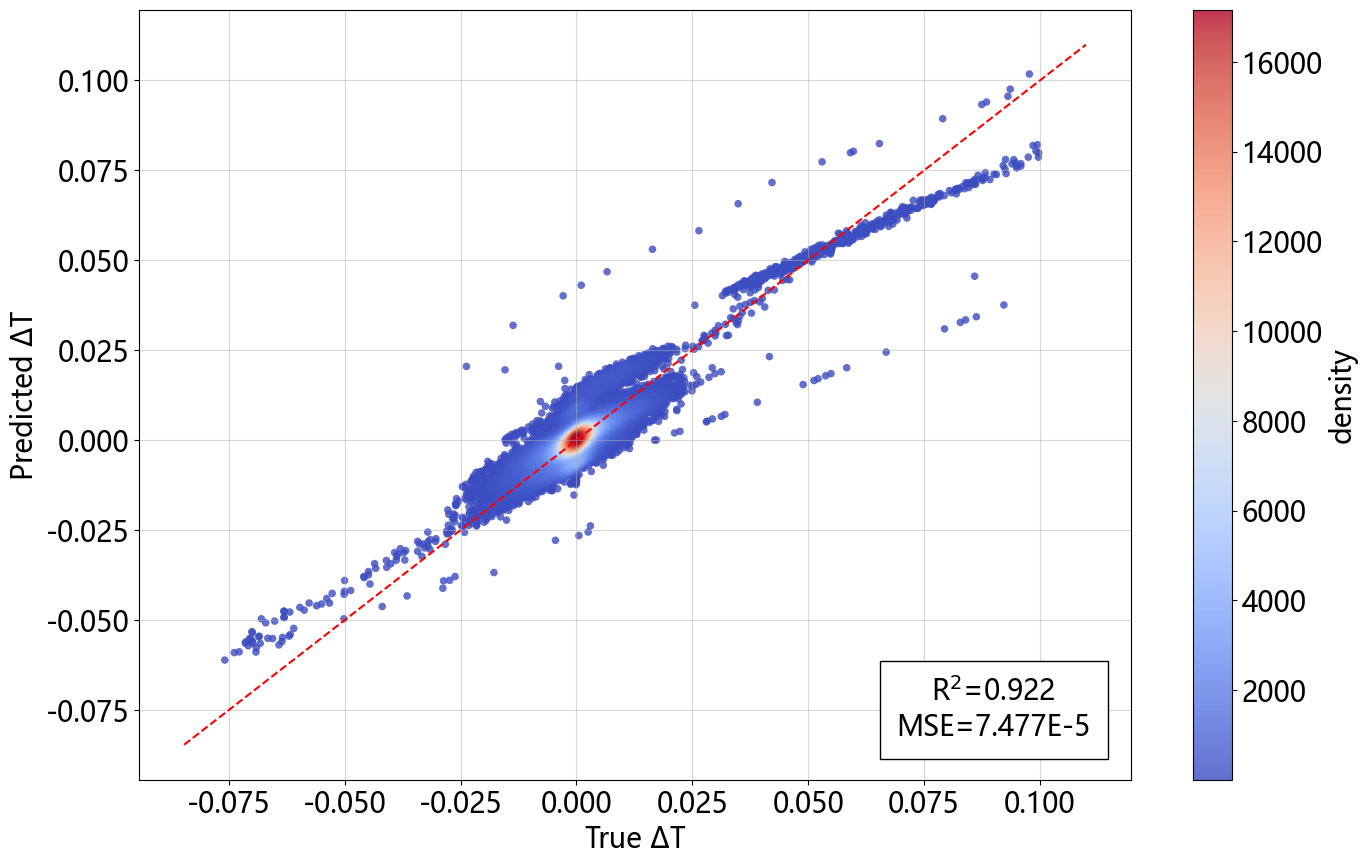

In [321]:
# 绘制散点图，颜色映射到密度
plt.figure(figsize=(16, 10))
sc = plt.scatter(
    x, y,
    c=z,
    s=30,               # 点大小
    cmap='coolwarm',     # 颜色映射
    edgecolor='none',   # 无边框
    alpha=0.8           # 透明度
)
plt.colorbar(sc, label='density')  # 添加颜色条

# 其余代码保持不变
ax = plt.gca()
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
diag_min = min(x_min, y_min)
diag_max = max(x_max, y_max)
plt.plot([diag_min, diag_max], [diag_min, diag_max], color='red', linestyle='--')
# plt.title('稳态热模型耦合结果', fontproperties=prop, fontsize=15)
plt.xlabel('True ΔT')
plt.ylabel('Predicted ΔT')

plt.grid(True, alpha=0.5)
# plt.text(0.09, -0.075, 'R$^2$=0.922', va='center', ha='center', fontsize=20)
# plt.text(0.09, -0.085, 'MSE=7.477E-5', va='center', ha='center', fontsize=20)

# 绘制空白框并添加文本
plt.text(
    x=0.09, y=-0.075,  # 文本框中心坐标（相对画布比例，0-1范围）
    s="R$^2$=0.922\nMSE=7.477E-5",  # 文本内容
    fontsize=20,    # 字体大小
    ha='center',    # 水平居中
    va='center',    # 垂直居中
    bbox=dict(      # 空白框样式设置
        facecolor='white',  # 框内填充色（白色=空白）
        edgecolor='black',  # 边框颜色
        boxstyle='square,pad=0.6'  # 框样式（round=圆角，pad=内边距）
    )
)